In [3]:
!pip install openai

   ---------------------------------------- 0.0/661.3 kB ? eta -:--:--
   ---------------------------------------- 661.3/661.3 kB 8.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 2.0/2.0 MB 54.6 MB/s eta 0:00:00
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.11.0
    Uninstalling typing_extensions-4.11.0:
      Successfully uninstalled typing_extensions-4.11.0


In [ ]:
import openai
from pathlib import Path
import os
import pickle

MiM_path = Path(os.getcwd()).parent
BASE = Path(MiM_path/'data')

with open(BASE/'labels/Kaggle_zhou.pkl','rb') as f:
    Zhou = pickle.load(f)

image_path = Zhou[Zhou.filename == '116_right.png'].file_path.item()
image_path

WindowsPath('c:/Users/gabim/MiM/data/raw-data/Kaggle/images/116_right.png')

In [14]:
Zhou[Zhou.filename == '116_right.png']

,filename,file_path,label
35581,116_right.png,c:\Users\gabim\MiM\data\raw-data\Kaggle\images...,0


In [ ]:
import openai
import base64

# 1. Tu API Key
openai.api_key = ["API_KEY"]

# 2. Ruta de tu imagen
image_path = 'c:/Users/gabim/MiM/data/raw-data/Kaggle/images/116_right.png'

# 3. Codificar imagen a base64
with open(image_path, "rb") as image_file:
    base64_image = base64.b64encode(image_file.read()).decode("utf-8")

# 4. Armar el contenido del mensaje
response = openai.chat.completions.create(
    model="gpt-4o",
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": "¿Esta imagen de fondo de ojo tiene calidad diagnóstica adecuada o no? Respondé solo 'Adecuada' o 'No adecuada'."
                },
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/jpeg;base64,{base64_image}"
                    }
                }
            ],
        }
    ],
    max_tokens=10,
)

# 5. Imprimir la respuesta
print("Respuesta:", response.choices[0].message.content)


Respuesta: No adecuada.


In [ ]:
import openai
import base64

openai.api_key = ["API_KEY"]

image_path = 'c:/Users/gabim/MiM/data/raw-data/Kaggle/images/116_right.png'

with open(image_path, "rb") as image_file:
    base64_image = base64.b64encode(image_file.read()).decode("utf-8")

prompt = (
    "Instruction: classify the image into two classes: 'Good quality', 'Poor quality'.\n"
    "Please first output one line with the predicted label.\n"
    "In the next line, provide a comprehensive explanation of your classification.\n"
    "Consider image quality aspects such as sharpness, brightness, contrast, and the visibility of anatomical structures like the optic disc, macula, and vessels."
)

response = openai.chat.completions.create(
    model="gpt-4o",
    messages=[
        {
            "role": "user",
            "content": [
                {"type": "text", "text": prompt},
                {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{base64_image}"}}
            ]
        }
    ],
    max_tokens=300,
)

print("Response:\n", response.choices[0].message.content)


Response:
 Poor quality

The image appears to lack sharpness, as the anatomical structures such as the optic disc, macula, and blood vessels are not clearly defined. The brightness and contrast seem inadequate, contributing to the difficulty in distinguishing key features. The overall visibility of important details is compromised, indicating a poor-quality image.


In [57]:
from pathlib import Path
import os
import sys
import pandas as pd
import numpy as np
import configparser

MiM_path = Path(os.getcwd()).parent
DIR = sys.path.append(MiM_path/'data')
BASE = Path(MiM_path/'data')

global_labels = configparser.ConfigParser()
global_labels.optionxform = str
global_labels.read(BASE/'labels/global_labels.ini')

['c:\\Users\\gabim\\MiM\\data\\labels\\global_labels.ini']

In [58]:
all_data = pd.DataFrame(global_labels['label'].items(), columns=['filename','label'])
all_data.label = all_data.label.astype(int)
all_data

,filename,label
0,HRF - Quality/10_bad,1
1,HRF - Quality/10_good,0
2,HRF - Quality/11_bad,1
3,HRF - Quality/11_good,0
4,HRF - Quality/12_bad,1
...,...,...
104005,Deep-Diabetic-Retinopathy-Image-Dataset-DeepDR...,1
104006,Deep-Diabetic-Retinopathy-Image-Dataset-DeepDR...,1
104007,Deep-Diabetic-Retinopathy-Image-Dataset-DeepDR...,1
104008,Deep-Diabetic-Retinopathy-Image-Dataset-DeepDR...,1


In [ ]:
global_bin = configparser.ConfigParser()
global_bin.read(BASE/'splits/global_binaria.ini')

train = pd.DataFrame({'filename': global_bin['split'].get('training').split(sep=','),'partition':'train'})

test = pd.DataFrame({'filename': global_bin['split'].get('test').split(sep=','),'partition':'test'})

test

,filename,partition
0,HRF - Quality/9_good,test
1,HRF - Quality/14_good,test
2,HRF - Quality/7_good,test
3,HRF - Quality/6_bad,test
4,HRF - Quality/10_bad,test
...,...,...
48376,Deep-Diabetic-Retinopathy-Image-Dataset-DeepDR...,test
48377,Deep-Diabetic-Retinopathy-Image-Dataset-DeepDR...,test
48378,Deep-Diabetic-Retinopathy-Image-Dataset-DeepDR...,test
48379,Deep-Diabetic-Retinopathy-Image-Dataset-DeepDR...,test


In [61]:
train = train.merge(all_data, how='inner',on ='filename')
train['img_path'] = train.filename.apply(lambda x: Path(os.getcwd()).parent/'data/images'/(x+'.png'))


test = test.merge(all_data, how='inner',on ='filename')
test['img_path'] = test.filename.apply(lambda x: Path(os.getcwd()).parent/'data/images'/(x+'.png'))
test

,filename,partition,label,img_path
0,HRF - Quality/9_good,test,0,c:\Users\gabim\MiM\data\images\HRF - Quality\9...
1,HRF - Quality/14_good,test,0,c:\Users\gabim\MiM\data\images\HRF - Quality\1...
2,HRF - Quality/7_good,test,0,c:\Users\gabim\MiM\data\images\HRF - Quality\7...
3,HRF - Quality/6_bad,test,1,c:\Users\gabim\MiM\data\images\HRF - Quality\6...
4,HRF - Quality/10_bad,test,1,c:\Users\gabim\MiM\data\images\HRF - Quality\1...
...,...,...,...,...
48376,Deep-Diabetic-Retinopathy-Image-Dataset-DeepDR...,test,1,c:\Users\gabim\MiM\data\images\Deep-Diabetic-R...
48377,Deep-Diabetic-Retinopathy-Image-Dataset-DeepDR...,test,1,c:\Users\gabim\MiM\data\images\Deep-Diabetic-R...
48378,Deep-Diabetic-Retinopathy-Image-Dataset-DeepDR...,test,1,c:\Users\gabim\MiM\data\images\Deep-Diabetic-R...
48379,Deep-Diabetic-Retinopathy-Image-Dataset-DeepDR...,test,1,c:\Users\gabim\MiM\data\images\Deep-Diabetic-R...


# Muestra 100

In [ ]:
# Tomar 50 de cada clase
df_poor = test[test['label'] == 1].sample(n=50, random_state=42)
df_good = test[test['label'] == 0].sample(n=50, random_state=42)

# Combinar y mezclar
df_sample = pd.concat([df_good, df_poor]).sample(frac=1, random_state=42).reset_index(drop=True)

# Guardar CSV
df_sample.to_csv("muestra_100_gpt4o.csv", index=False)

In [ ]:
import openai
import pandas as pd
import base64
from tqdm import tqdm

# CONFIGURACIÓN
openai.api_key = ["API_KEY"]
input_csv = "muestra_100_gpt4o.csv"
output_csv = "resultados_gpt4o_clasificacion_pura.csv"

# Prompt corto para clasificación pura
prompt = (
    "Classify the image as either 'Good quality' or 'Poor quality'."
    "Only respond with one of those two options."
)

# Cargar el CSV
df = pd.read_csv(input_csv)

# Lista para guardar los resultados
resultados = []

# Clasificar una por una
for _, row in tqdm(df.iterrows(), total=len(df)):
    img_path = str(row['img_path'])
    label_real = row['label']
    filename = row['filename']

    try:
        # Codificar imagen a base64
        with open(img_path, "rb") as image_file:
            base64_image = base64.b64encode(image_file.read()).decode("utf-8")

        # Llamar a la API
        response = openai.chat.completions.create(
            model="gpt-4o",
            messages=[
                {
                    "role": "user",
                    "content": [
                        {"type": "text", "text": prompt},
                        {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{base64_image}"}}
                    ],
                }
            ],
            max_tokens=10,
        )

        prediccion = response.choices[0].message.content.strip()
        resultados.append({
            "filename": filename,
            "real_label": label_real,
            "gpt4o_prediction": prediccion
        })

    except Exception as e:
        print(f"Error con {filename}: {e}")
        resultados.append({
            "filename": filename,
            "real_label": label_real,
            "gpt4o_prediction": "ERROR"
        })

# Guardar resultados
pd.DataFrame(resultados).to_csv(output_csv, index=False)
print(f"Clasificación terminada. Resultados guardados en: {output_csv}")


100%|██████████| 100/100 [02:29<00:00,  1.49s/it]

Clasificación terminada. Resultados guardados en: resultados_gpt4o_clasificacion_pura.csv


# Muestra 10.000

In [45]:
# Ver cuántas hay de cada clase
n_good_total = len(test[test['label'] == 0])
n_poor_total = len(test[test['label'] == 1])

# Queremos hasta 10.000 imágenes con la proporción real
proporcion_mala = n_poor_total/(n_good_total+n_poor_total)
proporcion_buena = 1 - proporcion_mala

print(f'Proporcion mala: {proporcion_mala}, Proporcion buena: {proporcion_buena}.')

# Calcular máximo que podemos tomar sin pasarnos
max_por_buenas = int(n_good_total / proporcion_buena)
max_por_malas = int(n_poor_total / proporcion_mala)
n_muestra_total = min(10_000, max_por_buenas, max_por_malas)

# Determinar cuántas por clase
n_good = int(n_muestra_total * proporcion_buena)
n_poor = n_muestra_total - n_good

print(f"Armando muestra de {n_muestra_total}: {n_good} buenas, {n_poor} malas")

# Muestrear
df_good = test[test['label'] == 0].sample(n=n_good, random_state=42)
df_poor = test[test['label'] == 1].sample(n=n_poor, random_state=42)

# # Mezclar
df_sample = pd.concat([df_good, df_poor]).sample(frac=1, random_state=42).reset_index(drop=True)

# Guardar CSV si querés
df_sample.to_csv("muestra_10000_gpt4o.csv", index=False)


Proporcion mala: 0.04266137533329199, Proporcion buena: 0.957338624666708.
Armando muestra de 10000: 9573 buenas, 427 malas


## Zero-shot ICL (In-Context Learning)

In [ ]:
import openai
import pandas as pd
import base64
from tqdm import tqdm
import os

# CONFIGURACIÓN
openai.api_key = ["API_KEY"]
input_csv = "muestra_10000_gpt4o.csv"
df = pd.read_csv(input_csv)

bloque_size = 1000
output_folder = "resultados_gpt4o"
os.makedirs(output_folder, exist_ok=True)

# PROMPT corto para clasificación pura
prompt = (
    "Classify the image as either 'Good quality' or 'Poor quality'. "
    "Only respond with one of those two options."
)

# FUNCIÓN PARA NORMALIZAR RESPUESTA
def normalizar_prediccion(pred):
    pred = pred.strip().lower().replace('.', '')
    if pred == "good quality":
        return 0 
    elif pred == "poor quality":
        return 1
    else:
        return "ERROR"

# RECORRER POR BLOQUES
total = len(df)
for i in range(0, total, bloque_size):
    bloque_df = df.iloc[i:i+bloque_size].copy()
    resultados = []

    print(f"🔹 Procesando imágenes {i+1} a {i+len(bloque_df)}...")

    for _, row in tqdm(bloque_df.iterrows(), total=len(bloque_df)):
        img_path = str(row['img_path'])
        real_label = row['label']
        filename = row['filename']

        try:
            with open(img_path, "rb") as image_file:
                base64_img = base64.b64encode(image_file.read()).decode("utf-8")

            response = openai.chat.completions.create(
                model="gpt-4o",
                messages=[
                    {
                        "role": "user",
                        "content": [
                            {"type": "text", "text": prompt},
                            {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{base64_img}"}}
                        ]
                    }
                ],
                max_tokens=10,
            )

            raw_pred = response.choices[0].message.content
            pred_label = normalizar_prediccion(raw_pred)

        except Exception as e:
            print(f"❌ Error con {filename}: {e}")
            pred_label = "ERROR"

        resultados.append({
            "filename": filename,
            "real_label": real_label,
            "gpt4o_prediction": pred_label
        })

    # Guardar bloque
    bloque_n = (i // bloque_size) + 1
    bloque_path = os.path.join(output_folder, f"resultados_gpt4o_bloque_{bloque_n}.csv")
    pd.DataFrame(resultados).to_csv(bloque_path, index=False)
    print(f"✅ Guardado: {bloque_path}")


🔹 Procesando imágenes 1 a 1000...


100%|██████████| 1000/1000 [29:35<00:00,  1.78s/it] 


✅ Guardado: resultados_gpt4o\resultados_gpt4o_bloque_1.csv
🔹 Procesando imágenes 1001 a 2000...


100%|██████████| 1000/1000 [24:05<00:00,  1.45s/it] 


✅ Guardado: resultados_gpt4o\resultados_gpt4o_bloque_2.csv
🔹 Procesando imágenes 2001 a 3000...


...

✅ Guardado: resultados_gpt4o\resultados_gpt4o_bloque_8.csv
🔹 Procesando imágenes 8001 a 9000...


100%|██████████| 1000/1000 [26:27<00:00,  1.59s/it] 


✅ Guardado: resultados_gpt4o\resultados_gpt4o_bloque_9.csv
🔹 Procesando imágenes 9001 a 10000...


100%|██████████| 1000/1000 [24:42<00:00,  1.48s/it] 

✅ Guardado: resultados_gpt4o\resultados_gpt4o_bloque_10.csv


In [49]:
import pandas as pd
import glob
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Cargar todos los bloques
carpeta_resultados = "resultados_gpt4o"
archivos = sorted(glob.glob(f"{carpeta_resultados}/resultados_gpt4o_bloque_*.csv"))

# 2. Concatenar todos los bloques
df_total = pd.concat([pd.read_csv(archivo) for archivo in archivos], ignore_index=True)

df_total.to_csv("resultados_gpt4o_completo.csv", index=False)

# 3. Filtrar solo filas válidas (sin errores)
df_valido = df_total[df_total['gpt4o_prediction'].isin([0, 1])].copy()

# 4. Cálculo de métricas
y_true = df_valido['real_label']
y_pred = df_valido['gpt4o_prediction']

print("🔎 Accuracy general:", round(accuracy_score(y_true, y_pred), 4))
print("\n📋 Classification report:")
print(classification_report(y_true, y_pred, target_names=["Good quality (0)", "Poor quality (1)"]))

print("\n🧱 Matriz de confusión:")
print(confusion_matrix(y_true, y_pred))


🔎 Accuracy general: 0.632

📋 Classification report:
                  precision    recall  f1-score   support

Good quality (0)       0.98      0.63      0.77      9573
Poor quality (1)       0.08      0.69      0.14       427

        accuracy                           0.63     10000
       macro avg       0.53      0.66      0.45     10000
    weighted avg       0.94      0.63      0.74     10000


🧱 Matriz de confusión:
[[6025 3548]
 [ 132  295]]


In [48]:
errores = df_total[df_total['gpt4o_prediction'] == "ERROR"]
print(f"❌ Errores de clasificación: {len(errores)}")


❌ Errores de clasificación: 0


In [53]:
# Las imagenes que agregue con Visualizacion Grad-CAM en la tesis quiero ver como las clasifica GPT-4o
# y en que se basa para esa clasificacion
test.iloc[[20284, 48314, 28127]]

,filename,partition,label,img_path
20284,Kaggle/25049_right,test,1,c:\Users\gabim\MiM\data\images\Kaggle\25049_ri...
48314,Deep-Diabetic-Retinopathy-Image-Dataset-DeepDR...,test,1,c:\Users\gabim\MiM\data\images\Deep-Diabetic-R...
28127,Kaggle/32414_left,test,0,c:\Users\gabim\MiM\data\images\Kaggle\32414_le...


### Predicción + Explicación

In [ ]:
import openai
import pandas as pd
import base64
import os


# CONFIGURACIÓN
openai.api_key = ["API_KEY"]

# PROMPT solicitacion explicacion
prompt = (
    "Instruction: classify the image as either 'Good quality' or 'Poor quality'.\n"
    "Please first output one line with the predicted label.\n"
    "In the next line, provide a comprehensive explanation of your classification.\n"
    "Consider image quality aspects such as sharpness, brightness, contrast, and the visibility of anatomical structures like the optic disc, macula, and vessels."
)

# FUNCIÓN PARA NORMALIZAR RESPUESTA
def normalizar_prediccion(pred):
    pred = pred.strip().lower().replace('.', '')
    if pred == "good quality":
        return 0 
    elif pred == "poor quality":
        return 1
    else:
        return "ERROR"

for _,row in test.iloc[[20284, 48314, 28127]].iterrows():
    img_path = str(row['img_path'])
    real_label = row['label']
    filename = row['filename']

    try:
        with open(img_path, "rb") as image_file:
            base64_img = base64.b64encode(image_file.read()).decode("utf-8")

        response = openai.chat.completions.create(
            model="gpt-4o",
            messages=[
                {
                    "role": "user",
                    "content": [
                        {"type": "text", "text": prompt},
                        {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{base64_img}"}}
                    ]
                }
            ],
            max_tokens=300,
        )

        print(f"Image: {filename}\nLabel: {real_label}\nResponse:\n", response.choices[0].message.content)

    except Exception as e:
        print(f"❌ Error con {filename}: {e}")
        pred_label = "ERROR"

Image: Kaggle/25049_right
Label: 1
Response:
 Good quality

The image exhibits clear visibility of key anatomical structures such as the optic disc, macula, and blood vessels. The sharpness is adequate, with distinct and well-defined vessel outlines. The brightness and contrast levels are balanced, helping to highlight important details and ensuring that the overall view is not obscured by excessive dark or bright areas.
Image: Deep-Diabetic-Retinopathy-Image-Dataset-DeepDRiD-/399_l2
Label: 1
Response:
 Good quality

The image is classified as 'Good quality' because it demonstrates clear visibility of essential anatomical structures such as the optic disc, macula, and vessels. The sharpness is sufficient, with distinct outlines of the retinal features. The brightness and contrast are well-balanced, providing a clear view of the different elements within the eye.
Image: Kaggle/32414_left
Label: 0
Response:
 Poor quality

The image is classified as poor quality because it lacks sufficien

In [ ]:
import openai
import pandas as pd
import base64
import os


# CONFIGURACIÓN
openai.api_key = ["API_KEY"]

# PROMPT solicitacion explicacion y agregando consideraciones sobre los artefactos en la imagen
prompt = (
    "Instruction: classify the image as either 'Good quality' or 'Poor quality'.\n"
    "Please first output one line with the predicted label.\n"
    "In the next line, provide a comprehensive explanation of your classification.\n"
    "Consider image quality aspects such as sharpness, brightness, contrast, and the visibility of anatomical structures like the optic disc, macula, and vessels. \
    Also consider the presence of image artifacts such as glare, reflections, vignetting,\
    blurred edges, or any other technical issues that may impair diagnostic usability."
)


# FUNCIÓN PARA NORMALIZAR RESPUESTA
def normalizar_prediccion(pred):
    pred = pred.strip().lower().replace('.', '')
    if pred == "good quality":
        return 0 
    elif pred == "poor quality":
        return 1
    else:
        return "ERROR"

for _,row in test.iloc[[20284, 48314, 28127]].iterrows():
    img_path = str(row['img_path'])
    real_label = row['label']
    filename = row['filename']

    try:
        with open(img_path, "rb") as image_file:
            base64_img = base64.b64encode(image_file.read()).decode("utf-8")

        response = openai.chat.completions.create(
            model="gpt-4o",
            messages=[
                {
                    "role": "user",
                    "content": [
                        {"type": "text", "text": prompt},
                        {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{base64_img}"}}
                    ]
                }
            ],
            max_tokens=300,
        )

        print(f"Image: {filename}\nLabel: {real_label}\nResponse:\n", response.choices[0].message.content)

    except Exception as e:
        print(f"❌ Error con {filename}: {e}")
        pred_label = "ERROR"

Image: Kaggle/25049_right
Label: 1
Response:
 Poor quality

The image is classified as poor quality due to several factors: 

1. **Sharpness**: The image appears blurry, and the details of anatomical structures like the optic disc and macula may not be clearly visible.
2. **Brightness and Contrast**: The image seems to lack the proper balance of brightness and contrast, making it difficult to distinguish between different structures.
3. **Artifacts**: There is a noticeable glare at the center, which could obscure important diagnostic features. Additionally, there is some vignetting around the edges, further diminishing image usability.
4. **Visibility of Structures**: Given the blurriness and glare, it may be challenging to accurately assess the vessels and other critical areas for diagnostic purposes.

Overall, these issues significantly impair the diagnostic usability of the image.
Image: Deep-Diabetic-Retinopathy-Image-Dataset-DeepDRiD-/399_l2
Label: 1
Response:
 Poor quality

The i

## Few-shots ICL (In-Context Learning)

### Ejemplo

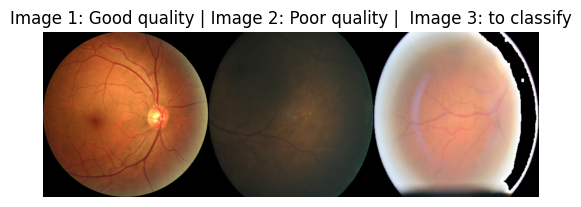

In [75]:
from PIL import Image
import matplotlib.pyplot as plt

# Paths a tus imágenes
img_buena_path = train[train['label'] == 0].sample(n=1, random_state=42).img_path.item()
img_mala_path = train[train['label'] == 1].sample(n=1, random_state=42).img_path.item()


input_csv = "muestra_10000_gpt4o.csv"
muestra_10K = pd.read_csv(input_csv)


img_actual_path = muestra_10K[muestra_10K['label'] == 1].sample(n=1, random_state=42).img_path.item()

# Abrir 
img1 = Image.open(img_buena_path).convert("RGB")
img2 = Image.open(img_mala_path).convert("RGB")
img3 = Image.open(img_actual_path).convert("RGB")

# Unir horizontalmente
ancho_total = img1.width + img2.width + img3.width
alto = img1.height
imagen_combinada = Image.new("RGB", (ancho_total, alto))
imagen_combinada.paste(img1, (0, 0))
imagen_combinada.paste(img2, (img1.width, 0))
imagen_combinada.paste(img3, (img1.width + img2.width, 0))

# Mostrar la imagen
plt.imshow(imagen_combinada)
plt.axis("off")
plt.title("Image 1: Good quality | Image 2: Poor quality |  Image 3: to classify")
plt.show()

# Guardar temporalmente
imagen_combinada.save("composite_test.jpg")


In [ ]:
import openai
import base64

# Clave API
openai.api_key = ["API_KEY"]

# Codificar imagen compuesta en base64
with open("composite_test.jpg", "rb") as image_file:
    img_base64 = base64.b64encode(image_file.read()).decode("utf-8")

# Prompt tipo ICL2
prompt = (
    "Instruction: classify the images into two classes: 'Good quality', 'Poor quality'.\n\n"
    "Example: the label of the above images:\n"
    "Image 1: Good quality\n"
    "Image 2: Poor quality\n\n"
    "Please output one line with the predicted label for Image 3."
)

# Enviar a la API
response = openai.chat.completions.create(
    model="gpt-4o",
    messages=[
        {
            "role": "user",
            "content": [
                {"type": "text", "text": prompt},
                {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{img_base64}"}}
            ]
        }
    ],
    max_tokens=10
)

# Ver resultado
print("Predicción:", response.choices[0].message.content.strip())


Predicción: Image 3: Poor quality


### Prediccion sobre toda la muestra de 10K

In [ ]:
import pandas as pd
import openai
import base64
import os
from tqdm import tqdm
from PIL import Image
import re

# CONFIGURACIÓN
openai.api_key = ["API_KEY"]
csv_path = "muestra_10000_gpt4o.csv"
img_buena_path = train[train['label'] == 0].sample(n=1, random_state=42).img_path.item()
img_mala_path = train[train['label'] == 1].sample(n=1, random_state=42).img_path.item()

bloque_size = 1000
output_folder = "resultados_gpt4o_icl2"
os.makedirs(output_folder, exist_ok=True)


# FUNC: unir 3 imágenes (buena, mala, actual)
def combinar_imagenes(img1_path, img2_path, img3_path):
    img1 = Image.open(img1_path).convert("RGB")
    img2 = Image.open(img2_path).convert("RGB")
    img3 = Image.open(img3_path).convert("RGB")
    ancho_total = img1.width + img2.width + img3.width
    alto = img1.height
    canvas = Image.new("RGB", (ancho_total, alto))
    canvas.paste(img1, (0, 0))
    canvas.paste(img2, (img1.width, 0))
    canvas.paste(img3, (img1.width + img2.width, 0))
    return canvas

# FUNC: codificar imagen PIL a base64
def encode_image_base64(img_pil):
    from io import BytesIO
    buffer = BytesIO()
    img_pil.save(buffer, format="JPEG")
    return base64.b64encode(buffer.getvalue()).decode("utf-8")

# FUNC: normalizar predicción
def normalizar(pred):
    pred = pred.lower().strip()
    match = re.search(r"(good quality|poor quality)", pred)
    if not match:
        return "ERROR"
    clase = match.group(1)
    return 0 if clase == "good quality" else 1


# PROMPT ICL2
prompt = (
    "Instruction: classify the images into two classes: 'Good quality', 'Poor quality'.\n\n"
    "Example: the label of the above images:\n"
    "Image 1: Good quality\n"
    "Image 2: Poor quality\n\n"
    "Please output one line with the predicted label for Image 3."
)

# Cargar muestra
df = pd.read_csv(csv_path)

# Clasificar en bloques de 1000
for i in range(0, len(df), bloque_size):
    bloque = df.iloc[i:i+bloque_size].copy()
    resultados = []

    print(f"🔄 Procesando bloque {i+1} a {i+len(bloque)}")

    for _, row in tqdm(bloque.iterrows(), total=len(bloque)):
        try:
            img_actual_path = str(row["img_path"])
            label_real = row["label"]
            filename = row["filename"]

            # Crear imagen combinada
            img_comb = combinar_imagenes(img_buena_path, img_mala_path, img_actual_path)
            img_b64 = encode_image_base64(img_comb)

            # Enviar a GPT-4o
            response = openai.chat.completions.create(
                model="gpt-4o",
                messages=[
                    {
                        "role": "user",
                        "content": [
                            {"type": "text", "text": prompt},
                            {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{img_b64}"}}
                        ]
                    }
                ],
                max_tokens=10,
            )

            pred_raw = response.choices[0].message.content
            pred_label = normalizar(pred_raw)

        except Exception as e:
            print(f"❌ Error con {row['filename']}: {e}")
            pred_label = "ERROR"

        resultados.append({
            "filename": filename,
            "real_label": label_real,
            "raw_response": pred_raw,
            "gpt4o_prediction": pred_label
        })


    # Guardar bloque
    bloque_n = (i // bloque_size) + 1
    pd.DataFrame(resultados).to_csv(f"{output_folder}/icl2_bloque_{bloque_n}.csv", index=False)
    print(f"✅ Bloque {bloque_n} guardado")
# $ 17.07 USD

🔄 Procesando bloque 1 a 1000


  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [27:08<00:00,  1.63s/it] 


✅ Bloque 1 guardado
🔄 Procesando bloque 1001 a 2000


100%|██████████| 1000/1000 [26:49<00:00,  1.61s/it] 


...

✅ Bloque 8 guardado
🔄 Procesando bloque 8001 a 9000


100%|██████████| 1000/1000 [30:10<00:00,  1.81s/it] 


✅ Bloque 9 guardado
🔄 Procesando bloque 9001 a 10000


100%|██████████| 1000/1000 [30:17<00:00,  1.82s/it] 

✅ Bloque 10 guardado


In [96]:
errores = df_total[df_total['gpt4o_prediction'] == "ERROR"]
print(f"❌ Errores de clasificación: {len(errores)}")

❌ Errores de clasificación: 10000


In [97]:
import pandas as pd
import glob
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Cargar todos los bloques
carpeta_resultados = "resultados_gpt4o_icl2"
archivos = sorted(glob.glob(f"{carpeta_resultados}/icl2_bloque_*.csv"))

# 2. Concatenar todos los bloques
df_total = pd.concat([pd.read_csv(archivo) for archivo in archivos], ignore_index=True)

df_total.to_csv("resultados_gpt4o_icl2_completo.csv", index=False)

# 3. Filtrar solo filas válidas (sin errores)
df_valido = df_total[df_total['gpt4o_prediction'].isin([0, 1])].copy()

# 4. Cálculo de métricas
y_true = df_valido['real_label']
y_pred = df_valido['gpt4o_prediction']

print("🔎 Accuracy general:", round(accuracy_score(y_true, y_pred), 4))
print("\n📋 Classification report:")
print(classification_report(y_true, y_pred, target_names=["Good quality (0)", "Poor quality (1)"]))

print("\n🧱 Matriz de confusión:")
print(confusion_matrix(y_true, y_pred))

🔎 Accuracy general: 0.5229

📋 Classification report:
                  precision    recall  f1-score   support

Good quality (0)       0.98      0.51      0.67      9573
Poor quality (1)       0.07      0.78      0.12       427

        accuracy                           0.52     10000
       macro avg       0.52      0.65      0.40     10000
    weighted avg       0.94      0.52      0.65     10000


🧱 Matriz de confusión:
[[4895 4678]
 [  93  334]]


### Predicción + Explicación

In [ ]:
import openai
import pandas as pd
import base64
import os


# CONFIGURACIÓN
openai.api_key = ["API_KEY"]
img_buena_path = train[train['label'] == 0].sample(n=1, random_state=42).img_path.item()
img_mala_path = train[train['label'] == 1].sample(n=1, random_state=42).img_path.item()

# PROMPT solicitacion explicacion
prompt = (
    "Instruction: classify the images into two classes: 'Good quality', 'Poor quality'.\n\n"
    "Example: the label of the above images:\n"
    "Image 1: Good quality\n"
    "Image 2: Poor quality\n\n"
    "Please output one line with the predicted label for Image 3."
    "In the next line, provide a comprehensive explanation of your classification.\n"
    "Consider image quality aspects such as sharpness, brightness, contrast, and the visibility of anatomical structures like the optic disc, macula, and vessels."
)

# FUNC: unir 3 imágenes (buena, mala, actual)
def combinar_imagenes(img1_path, img2_path, img3_path):
    img1 = Image.open(img1_path).convert("RGB")
    img2 = Image.open(img2_path).convert("RGB")
    img3 = Image.open(img3_path).convert("RGB")
    ancho_total = img1.width + img2.width + img3.width
    alto = img1.height
    canvas = Image.new("RGB", (ancho_total, alto))
    canvas.paste(img1, (0, 0))
    canvas.paste(img2, (img1.width, 0))
    canvas.paste(img3, (img1.width + img2.width, 0))
    return canvas

# FUNC: codificar imagen PIL a base64
def encode_image_base64(img_pil):
    from io import BytesIO
    buffer = BytesIO()
    img_pil.save(buffer, format="JPEG")
    return base64.b64encode(buffer.getvalue()).decode("utf-8")

# FUNC: normalizar predicción
def normalizar(pred):
    pred = pred.lower().strip()
    match = re.search(r"(good quality|poor quality)", pred)
    if not match:
        return "ERROR"
    clase = match.group(1)
    return 0 if clase == "good quality" else 1

for _,row in test.iloc[[20284, 48314, 28127]].iterrows():
    img_path = str(row['img_path'])
    real_label = row['label']
    filename = row['filename']

    # Crear imagen combinada
    img_comb = combinar_imagenes(img_buena_path, img_mala_path, img_actual_path)
    img_b64 = encode_image_base64(img_comb)

    try:
        response = openai.chat.completions.create(
            model="gpt-4o",
            messages=[
                {
                    "role": "user",
                    "content": [
                        {"type": "text", "text": prompt},
                        {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{img_b64}"}}
                    ]
                }
            ],
            max_tokens=300,
        )

        print(f"Image: {filename}\nLabel: {real_label}\nResponse:\n", response.choices[0].message.content)

    except Exception as e:
        print(f"❌ Error con {filename}: {e}")
        pred_label = "ERROR"
# tengo 8.31 usd

Image: Kaggle/25049_right
Label: 1
Response:
 Image 3: Poor quality

The third image exhibits characteristics of poor quality. It appears to have lower brightness and contrast compared to a good quality image. The anatomical structures such as the optic disc, macula, and blood vessels are not as clearly visible or well-defined. These features make it difficult to assess the image for medical or diagnostic purposes, categorizing it as poor quality.
Image: Deep-Diabetic-Retinopathy-Image-Dataset-DeepDRiD-/399_l2
Label: 1
Response:
 Image 3: Poor quality

The image exhibits low brightness and contrast, making it difficult to clearly distinguish the anatomical structures like the optic disc, macula, and vessels. The sharpness is not sufficient to provide a clear and detailed view, which is crucial for a good quality classification.
Image: Kaggle/32414_left
Label: 0
Response:
 Image 3: Poor quality

The third image exhibits several signs of poor quality. It lacks adequate sharpness, making 